In [33]:
class Value:

    def __init__(self, data, _children=(), label = '', _op = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self.label = label
        self._op = _op
        self._backward = lambda : None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, {self, other}, _op = '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, {self, other}, _op = '*')

        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward
        return out 

    def __rmul__(self, other):
        return self * other 

    def __radd__(self, other):
        return self + other

    # def backward(self):


In [34]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it 
        dot.node(name = uid, label ="{ %s | data %.4f | grad%.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value a result of some operation, create op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [35]:
a = Value(2.0); a.label = 'a'
b = Value(-3.0); b.label = 'b'
e = a * b ; e.label = 'e'
c = Value(10.0); c.label = 'c'
d = e + c; d.label = 'd'
f = Value(-2.0); f.label = 'f'
L = f*d; L.label = 'L'

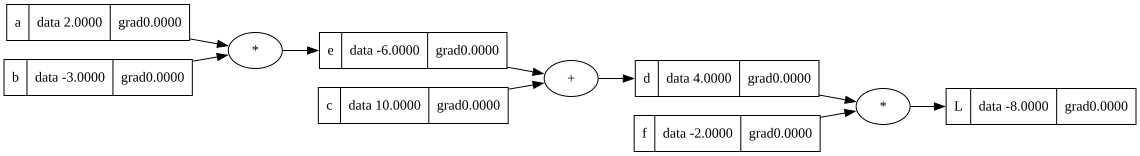

In [36]:
draw_dot(L)